### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Data Exploration Jupyter Notebook

Data Exploration conducted after Data Preparation and Cleaning

For this part I explore the relationships between each variable

First I create Histograms of the important variables

I then do Box plots, and group by country analysis 

I also conduct pair plot analysis of the major variables

Then I conducted correlation analysis with pearson, spearman and kandall tau

I then did a pair plot analysis of a selected set of variables that are more relevant to the analysis with a correlation matrix


### Link to each Dataset:

### ECI Petitions:
https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en ECI 01: Ban on conversion practices in the European Union

https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en ECI 02: European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe

https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en ECI 04: My Voice, My Choice: For Safe And Accessible Abortion

https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en ECI 06: Air-Quotas

https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en ECI 07: Stop Destroying Videogames

https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en ECI 08: Stop Cruelty Stop Slaughter

https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en ECI 09: STOP FAKE FOOD: ORIGIN ON LABEL

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

import scipy
from scipy import stats

from scipy.stats import kendalltau
from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [3]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "eci_merged_dataset.csv"
complete_file_name = file_path + file_name

In [4]:
merged_data = pd.read_csv(complete_file_name)

In [5]:
merged_data.head(10)

,Country,Signatures,Threshold,Percentage,Petition_ID,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita,Petition_Name
0,Austria,10724,13395,80.06,eci_table_01,8877067.0,4.463147e+11,109,4.67,85.1,81.6,5194416.0,60.7,0.001208,50277.275087,0.800597,0.001509,Ban Conversion Practices
1,Belgium,47459,14805,320.56,eci_table_01,11484055.0,5.296067e+11,383,5.59,79.7,81.6,11259082.0,53.6,0.004133,46116.699234,3.205606,0.001289,Ban Conversion Practices
2,Bulgaria,2386,11985,19.91,eci_table_01,6975761.0,8.600000e+10,64,4.34,71.0,74.9,5256027.0,55.4,0.000342,12328.404026,0.199082,0.001718,Ban Conversion Practices
3,Croatia,8574,8460,101.35,eci_table_01,4067500.0,6.041555e+10,73,6.93,67.9,78.1,2328318.0,51.2,0.002108,14853.239837,1.013475,0.002080,Ban Conversion Practices
4,Cyprus,696,4230,16.45,eci_table_01,1198575.0,2.456465e+10,131,7.27,75.9,80.8,800708.0,63.1,0.000581,20494.877613,0.164539,0.003529,Ban Conversion Practices
5,Czech Republic,3774,14805,25.49,eci_table_01,10669709.0,2.464892e+11,139,1.93,64.1,79.0,7887156.0,60.6,0.000354,23101.777705,0.254914,0.001388,Ban Conversion Practices
6,Denmark,8587,9870,87.00,eci_table_01,5818553.0,3.480780e+11,137,4.91,80.6,81.0,5119978.0,62.2,0.001476,59822.092961,0.870010,0.001696,Ban Conversion Practices
7,Estonia,1519,4935,30.78,eci_table_01,1331824.0,3.138695e+10,31,5.11,69.6,78.2,916024.0,63.6,0.001141,23566.890205,0.307801,0.003705,Ban Conversion Practices
8,Finland,23618,9870,239.29,eci_table_01,5520314.0,2.687612e+11,18,6.59,88.2,81.7,4716888.0,59.1,0.004278,48685.853987,2.392908,0.001788,Ban Conversion Practices
9,France,580568,55695,1042.41,eci_table_01,67059887.0,2.715518e+12,119,8.43,65.6,82.5,54123364.0,55.1,0.008657,40493.928572,10.424060,0.000831,Ban Conversion Practices


In [6]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                189 non-null    object 
 1   Signatures             189 non-null    int64  
 2   Threshold              189 non-null    int64  
 3   Percentage             189 non-null    float64
 4   Petition_ID            189 non-null    object 
 5   Population             189 non-null    float64
 6   GDP                    189 non-null    float64
 7   Population_Density     189 non-null    int64  
 8   Unemployment_Rate      189 non-null    float64
 9   Tertiary_Enrollment    189 non-null    float64
 10  Life_Expectancy        189 non-null    float64
 11  Urban_Population       189 non-null    float64
 12  Labor_Participation    189 non-null    float64
 13  Signatures_Per_Capita  189 non-null    float64
 14  GDP_Per_Capita         189 non-null    float64
 15  Thresh

In [7]:
print("Shape:", merged_data.shape)

Shape: (189, 18)


In [8]:
merged_data.describe()

,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita
count,189.000000,189.000000,189.000000,1.890000e+02,1.890000e+02,189.000000,189.000000,189.000000,189.000000,1.890000e+02,189.000000,189.000000,189.000000,189.000000,189.000000
mean,26547.243386,18408.333333,106.209683,1.657809e+07,5.781803e+11,176.592593,6.042593,71.255556,79.907407,1.238606e+07,58.444444,0.001727,34820.662358,1.062096,0.002159
std,82806.774516,16959.848909,201.748449,2.192177e+07,8.979297e+11,259.712112,3.244475,19.942922,2.711627,1.686423e+07,3.958607,0.003260,22240.070678,2.017483,0.001712
min,8.000000,4230.000000,0.110000,5.026530e+05,1.478616e+10,18.000000,1.930000,19.200000,74.700000,4.759020e+05,49.600000,0.000002,12328.404026,0.001114,0.000814
25%,109.000000,7755.000000,0.810000,2.786844e+06,6.041555e+10,72.000000,3.980000,63.900000,77.600000,1.891013e+06,55.400000,0.000018,19329.096801,0.008137,0.001202
50%,1519.000000,13395.000000,9.190000,8.877067e+06,2.464892e+11,109.000000,5.360000,70.200000,81.000000,5.256027e+06,59.100000,0.000231,25739.247814,0.091857,0.001515
75%,18313.000000,20445.000000,137.030000,1.733285e+07,5.308329e+11,139.000000,6.590000,80.600000,82.100000,1.125908e+07,61.600000,0.002431,48685.853987,1.370257,0.002701
max,841188.000000,67680.000000,1569.970000,8.313280e+07,3.845630e+12,1380.000000,17.240000,136.600000,83.300000,6.432484e+07,64.600000,0.028501,110172.373141,15.699664,0.008415


### Histogram of Signatures per Capita

<Axes: >

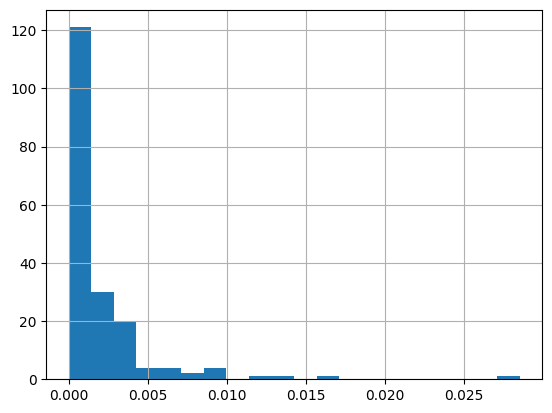

In [9]:
merged_data["Signatures_Per_Capita"].hist(
    bins=20
)

Participation rates are highly right skewed with most countries showing reltively low participation but a small number of countries showing really high engagement 

### Histogram of GDP per Capita

<Axes: >

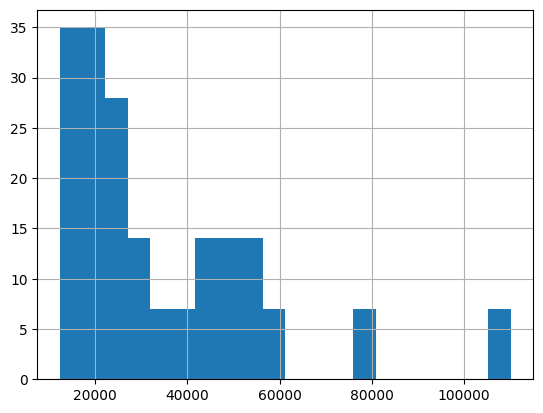

In [10]:
merged_data["GDP_Per_Capita"].hist(
    bins=20
)

GDP per capita right skewed varies across the EU with a few countries with really high with most countries with relatively high GDP per capita

### Histogram of Unemployment Rate

<Axes: >

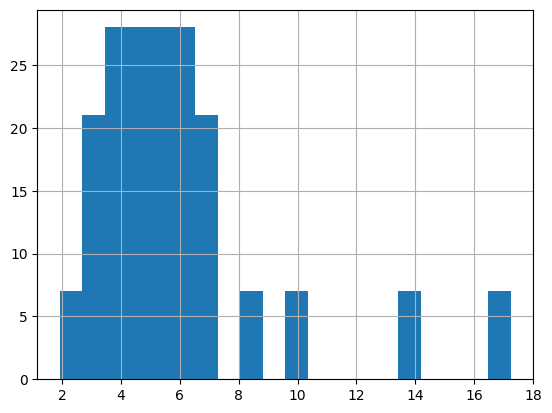

In [11]:
merged_data["Unemployment_Rate"].hist(
    bins=20
)

Unemployment rate across the EU is also right skewed with a large concentration of countries with relatively low unemployment rates

### Histogram of Population Density

<Axes: >

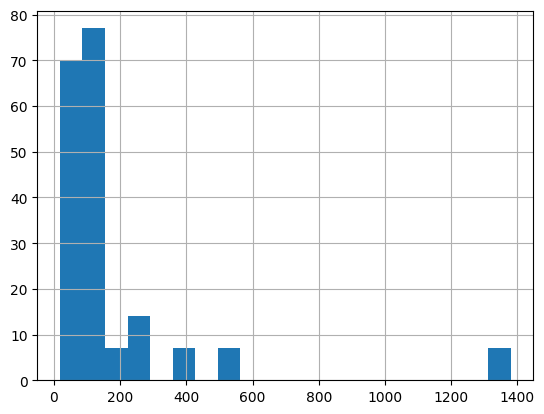

In [12]:
merged_data["Population_Density"].hist(
    bins=20
)

Population density across the EU is also right skewed with most countries having relatively lower population density and few with really high population density

<Axes: xlabel='GDP_Per_Capita'>

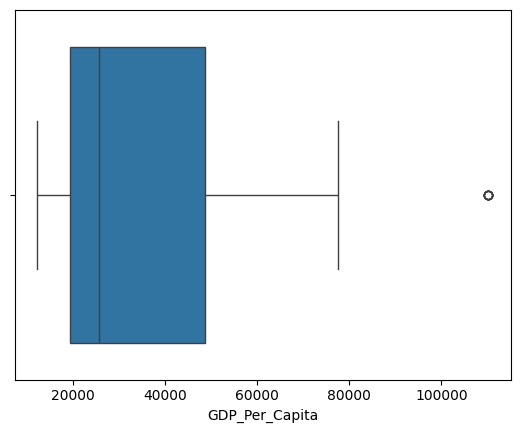

In [13]:
sns.boxplot(
    x=merged_data["GDP_Per_Capita"]
)

In [14]:
country_mean = (
    merged_data
    .groupby("Country")["Signatures_Per_Capita"]
    .mean()
    .sort_values(ascending=False)
)

<Axes: xlabel='Country'>

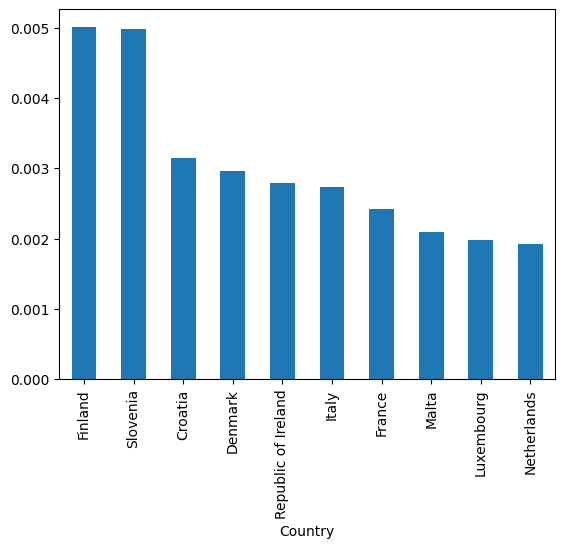

In [15]:
country_mean.head(10).plot.bar()

In [16]:
country_mean.tail(10)

Country
Greece            0.000993
Slovakia          0.000950
Austria           0.000936
Romania           0.000865
Portugal          0.000824
Poland            0.000747
Cyprus            0.000721
Hungary           0.000675
Czech Republic    0.000574
Bulgaria          0.000482
Name: Signatures_Per_Capita, dtype: float64

Average participation rates differ greatly between countries

This suggests that geographic or cultural factors may influence ECI signatures

Top 5 Countries:

- Finland
- Slovenia
- Croatia
- Denmark
- Ireland

<Axes: xlabel='Petition_ID', ylabel='Signatures_Per_Capita'>

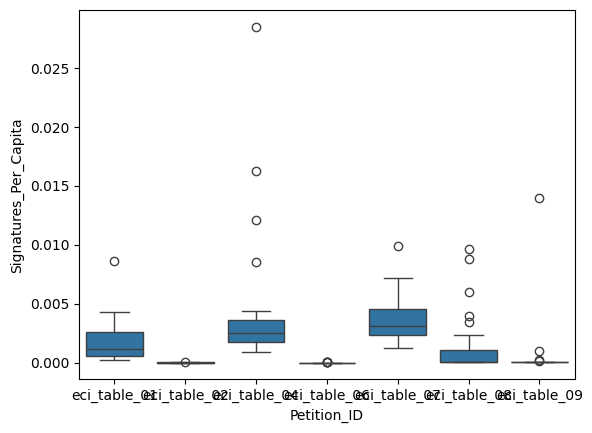

In [17]:
sns.boxplot(
    data=merged_data,
    x="Petition_ID",
    y="Signatures_Per_Capita"
)

In [18]:
merged_data.groupby("Petition_Name")["Signatures_Per_Capita"].describe()

,count,mean,std,min,25%,50%,75%,max
Petition_Name,,,,,,,,
Air-Quotas,27.0,0.000011,0.000015,0.000002,0.000003,0.000006,0.000008,0.000076
Ban Conversion Practices,27.0,0.001837,0.001861,0.000238,0.000545,0.001141,0.002632,0.008657
Defence of Agriculture,27.0,0.000011,0.000007,0.000004,0.000006,0.000009,0.000015,0.000035
My Voice My Choice,27.0,0.004418,0.005927,0.000939,0.001726,0.002531,0.003578,0.028501
STOP FAKE FOOD: ORIGIN ON LABEL,27.0,0.000599,0.002675,0.000019,0.000026,0.000038,0.000062,0.013951
Stop Cruelty Stop Slaughter,27.0,0.001409,0.002691,0.000017,0.000034,0.000064,0.001069,0.009640
Stop Destroying Videogames,27.0,0.003806,0.002077,0.001278,0.002382,0.003123,0.004591,0.009880


In [19]:
merged_data.groupby(
    "Petition_Name"
)["Signatures"].sum()

Petition_Name
Air-Quotas                            7278
Ban Conversion Practices           1128063
Defence of Agriculture                4432
My Voice My Choice                 1124513
STOP FAKE FOOD: ORIGIN ON LABEL     868587
Stop Cruelty Stop Slaughter         590368
Stop Destroying Videogames         1294188
Name: Signatures, dtype: int64

Participation rates vary greatly between differen petitions

This shows that petition specific characteristics may influence participation more than country level socio-economic variables

### Pair Plots

<Axes: xlabel='GDP_Per_Capita', ylabel='Signatures_Per_Capita'>

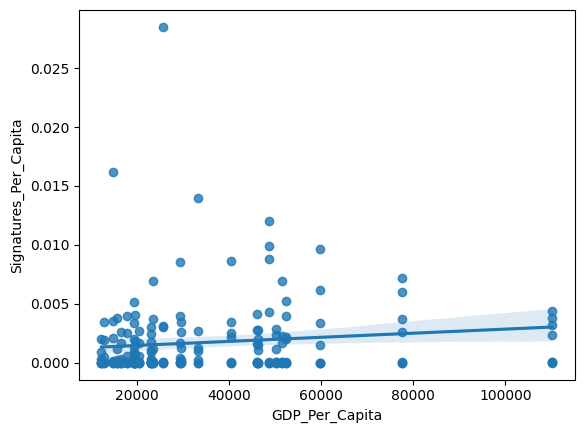

In [22]:
sns.regplot(
    data=merged_data,
    x="GDP_Per_Capita",
    y="Signatures_Per_Capita"
)

GDP per capita shows a weak positive relationship with Signatures per Capita

<Axes: xlabel='Unemployment_Rate', ylabel='Signatures_Per_Capita'>

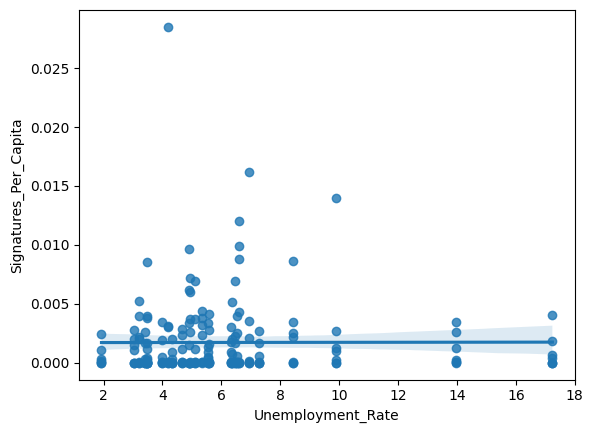

In [23]:
sns.regplot(
    data=merged_data,
    x="Unemployment_Rate",
    y="Signatures_Per_Capita"
)

Unemployment rate shows a little correlation of a linear relationship with Signatures per Capita

<Axes: xlabel='Tertiary_Enrollment', ylabel='Signatures_Per_Capita'>

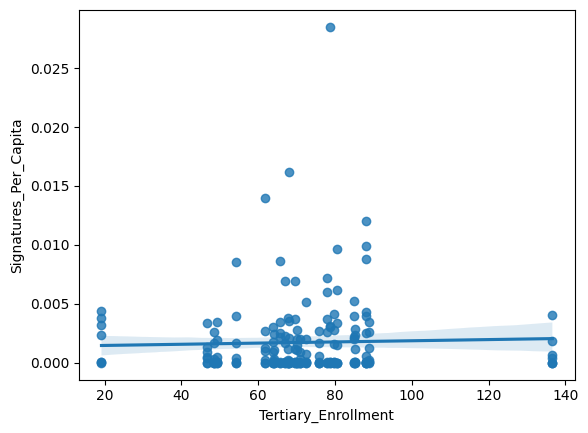

In [24]:
sns.regplot(
    data=merged_data,
    x="Tertiary_Enrollment",
    y="Signatures_Per_Capita"
)

Tertiary Enrollment shows minimal influence on Signatures per capita

<Axes: xlabel='Population_Density', ylabel='Signatures_Per_Capita'>

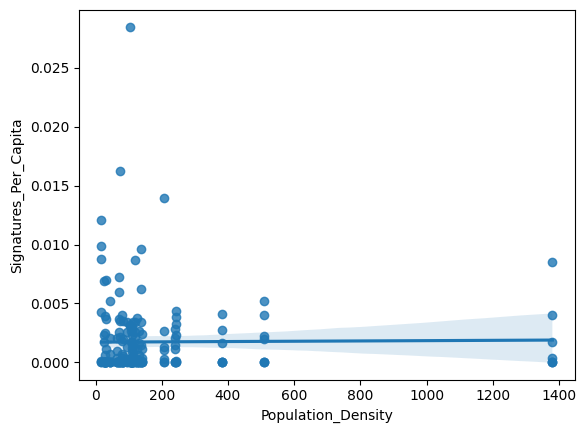

In [25]:
sns.regplot(
    data=merged_data,
    x="Population_Density",
    y="Signatures_Per_Capita"
)

Population Density also shows very little correlation with Signatures per capita

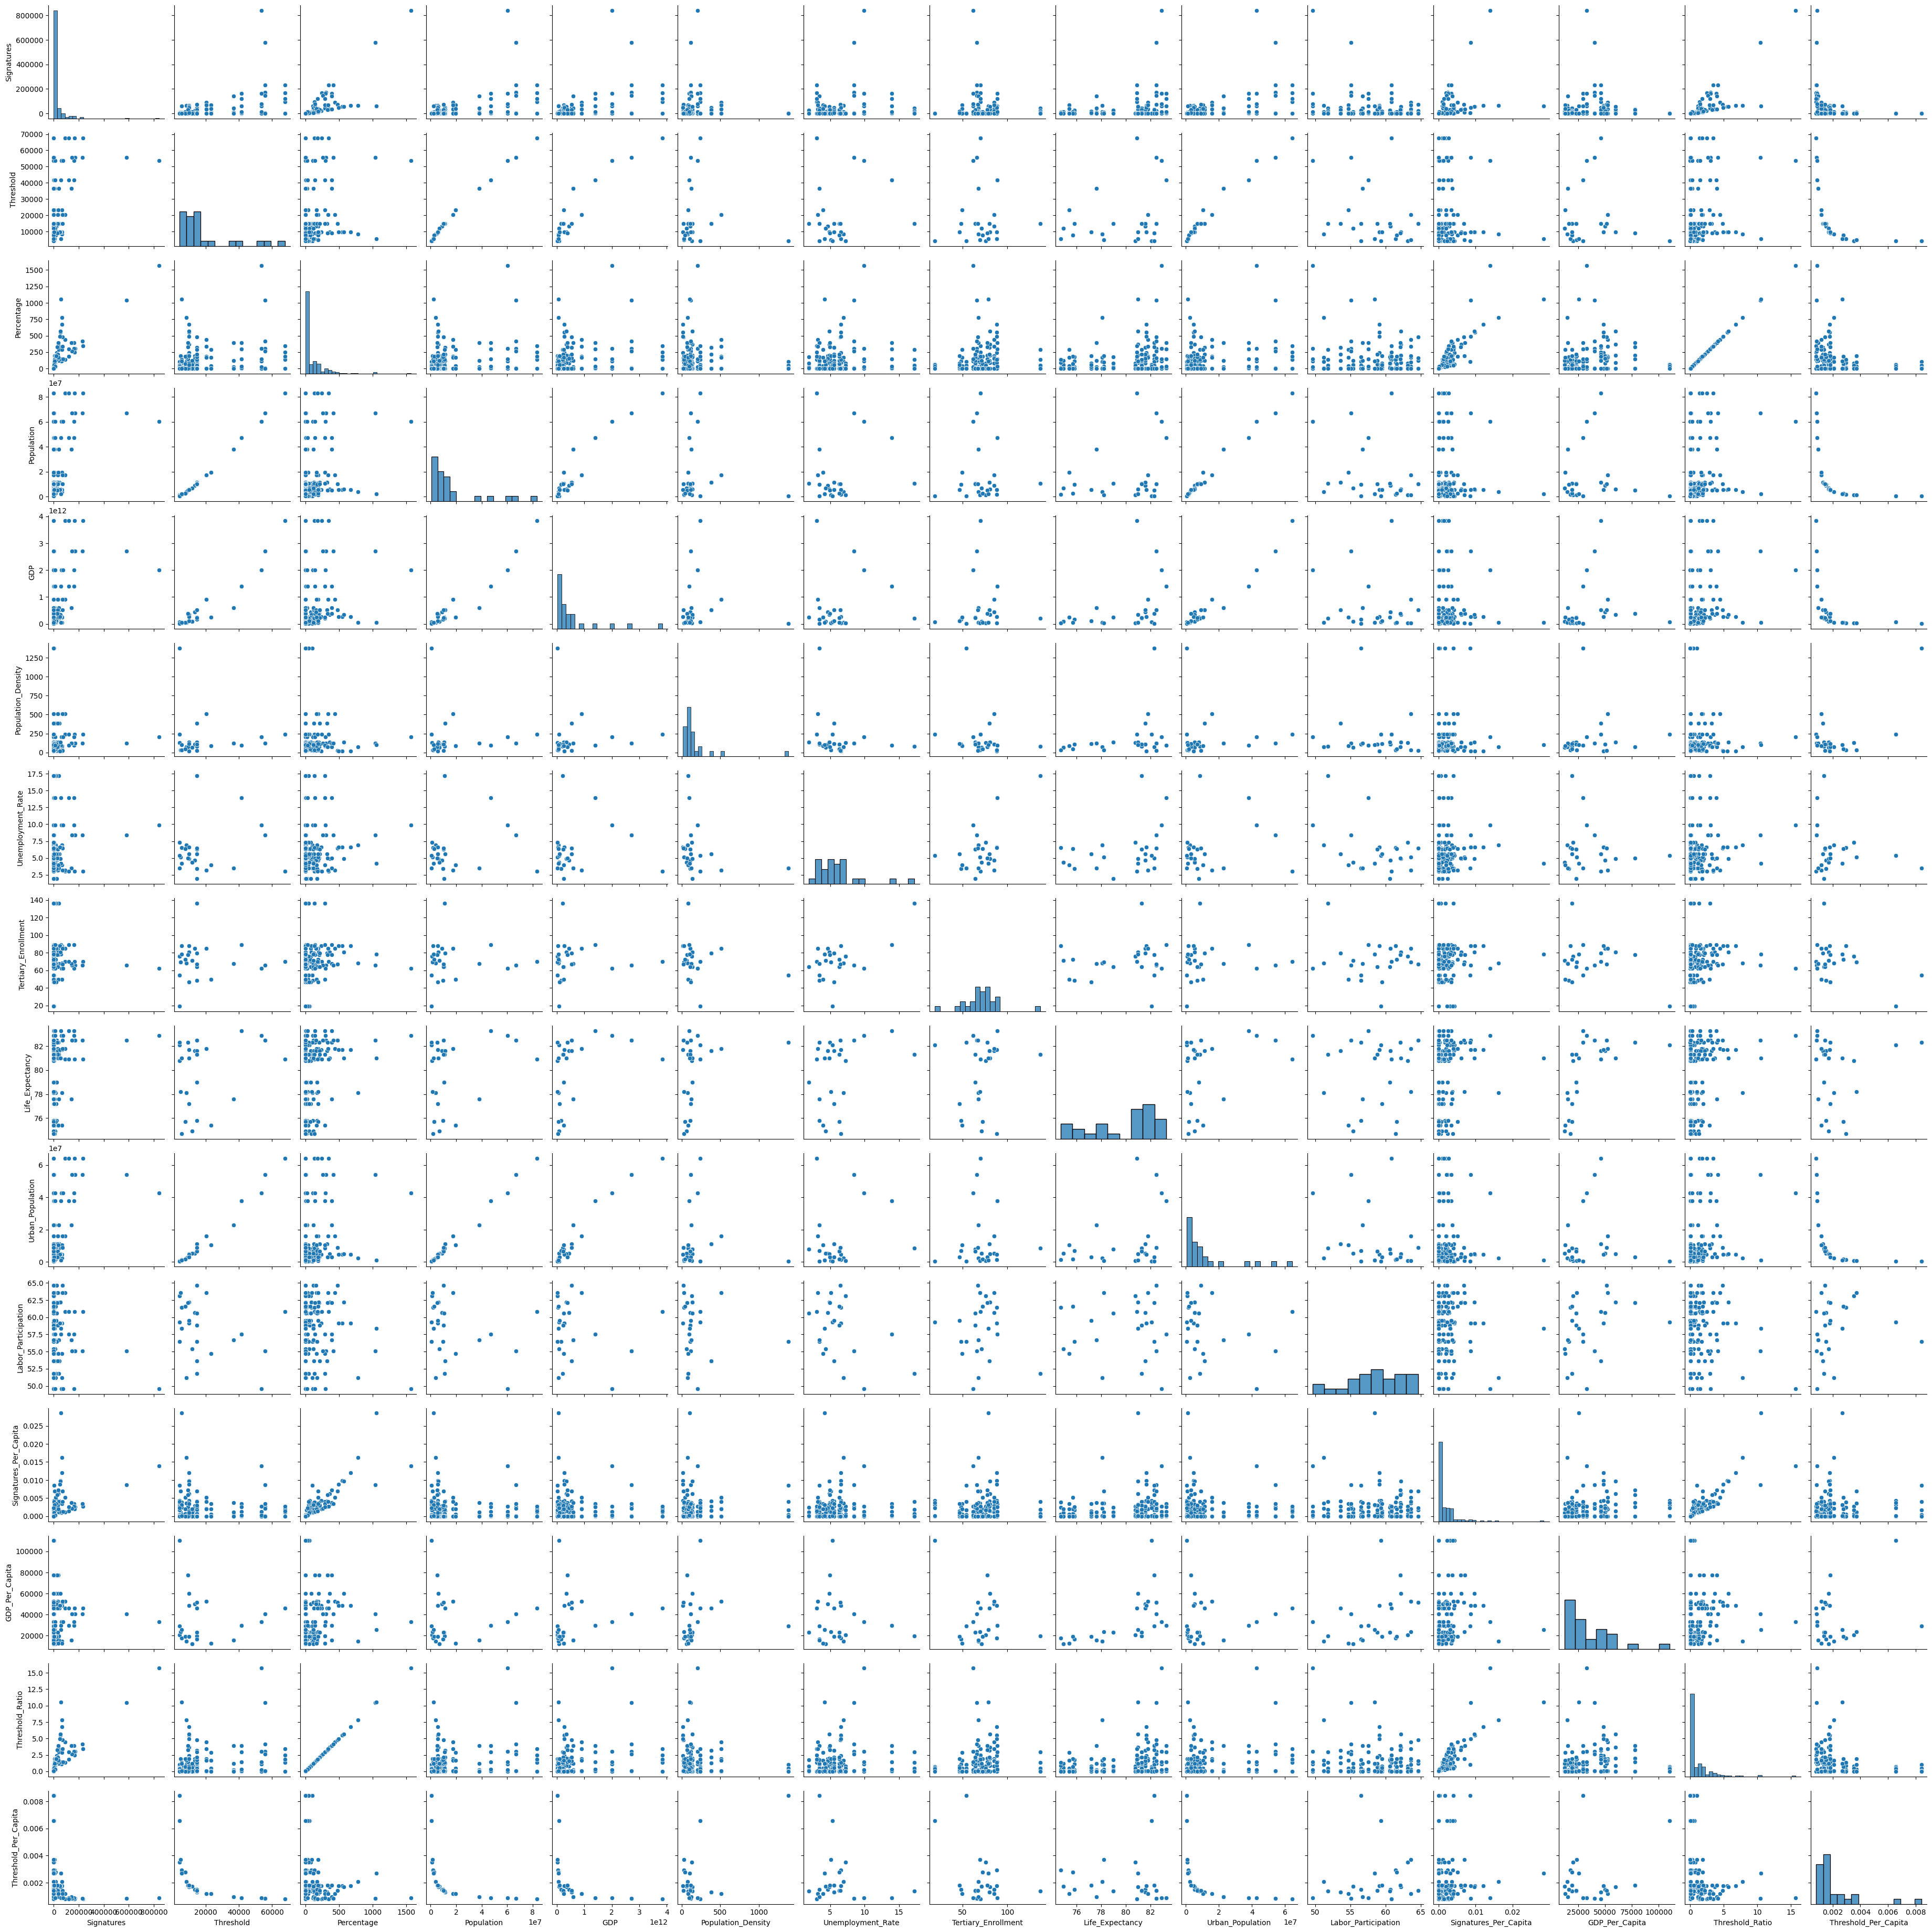

In [26]:
sns.pairplot(merged_data)
plt.show()

### Correlation Matrices

In [27]:
print("\nPearson correlation matrix:")
pearson_corr = merged_data.corr(method='pearson', numeric_only=True)
display(pearson_corr)

print("\nSpearman correlation matrix:")
spearman_corr = merged_data.corr(method='spearman', numeric_only=True)
display(spearman_corr)

print("\nKendall's Tau correlation matrix:")
kendall_corr = merged_data.corr(method='kendall', numeric_only=True)
display(kendall_corr)


Pearson correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita
Signatures,1.000000,0.445746,0.796448,0.448508,0.433711,-0.011355,0.137397,-0.010541,0.200604,0.449200,-0.196832,0.440637,0.041430,0.796448,-0.195666
Threshold,0.445746,1.000000,0.205550,0.996678,0.937842,-0.048438,0.178699,0.007127,0.261238,0.985980,-0.307761,-0.037899,-0.018794,0.205547,-0.509211
Percentage,0.796448,0.205550,1.000000,0.205957,0.215066,-0.051156,0.087875,0.070828,0.201194,0.211607,-0.110653,0.862973,0.094286,1.000000,-0.164591
Population,0.448508,0.996678,0.205957,1.000000,0.953559,-0.032074,0.180644,0.002419,0.280749,0.993291,-0.285849,-0.029345,0.001898,0.205954,-0.465433
GDP,0.433711,0.937842,0.215066,0.953559,1.000000,0.016229,0.107794,0.022954,0.372344,0.970793,-0.134201,0.000570,0.158442,0.215064,-0.401574
Population_Density,-0.011355,-0.048438,-0.051156,-0.032074,0.016229,1.000000,-0.226856,-0.186457,0.298356,-0.013816,-0.102084,0.010112,0.104264,-0.051155,0.630899
Unemployment_Rate,0.137397,0.178699,0.087875,0.180644,0.107794,-0.226856,1.000000,0.566670,0.315783,0.201126,-0.397667,0.002393,-0.103766,0.087872,-0.181670
Tertiary_Enrollment,-0.010541,0.007127,0.070828,0.002419,0.022954,-0.186457,0.566670,1.000000,0.174995,0.032185,-0.037182,0.030420,-0.214045,0.070826,-0.376790
Life_Expectancy,0.200604,0.261238,0.201194,0.280749,0.372344,0.298356,0.315783,0.174995,1.000000,0.324490,0.023834,0.146910,0.595434,0.201193,0.060256
Urban_Population,0.449200,0.985980,0.211607,0.993291,0.970793,-0.013816,0.201126,0.032185,0.324490,1.000000,-0.254142,-0.022964,0.038974,0.211604,-0.455504



Spearman correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita
Signatures,1.000000,0.414216,0.964143,0.417679,0.449205,0.091875,0.067264,0.057878,0.237290,0.417436,-0.132814,0.862190,0.160773,0.964155,-0.422086
Threshold,0.414216,1.000000,0.191704,0.993262,0.875865,0.205290,-0.047027,-0.025200,0.226207,0.988037,-0.325706,-0.068856,0.019361,0.191703,-0.986501
Percentage,0.964143,0.191704,1.000000,0.198892,0.264695,0.027959,0.082522,0.094634,0.205296,0.200890,-0.050666,0.954939,0.183527,0.999992,-0.206773
Population,0.417679,0.993262,0.198892,1.000000,0.885836,0.222833,-0.020150,0.036020,0.240721,0.993895,-0.331298,-0.062877,0.044567,0.198878,-0.996337
GDP,0.449205,0.875865,0.264695,0.885836,1.000000,0.244200,-0.002137,0.123321,0.496716,0.900488,-0.097710,0.027840,0.433455,0.264699,-0.898657
Population_Density,0.091875,0.205290,0.027959,0.222833,0.244200,1.000000,-0.361166,-0.298535,0.295708,0.208791,-0.136183,0.015987,0.300366,0.027728,-0.248474
Unemployment_Rate,0.067264,-0.047027,0.082522,-0.020150,-0.002137,-0.361166,1.000000,0.282705,0.313627,-0.014044,-0.213926,0.078446,0.007022,0.082338,0.017097
Tertiary_Enrollment,0.057878,-0.025200,0.094634,0.036020,0.123321,-0.298535,0.282705,1.000000,0.113945,0.053114,0.207328,0.045695,0.217338,0.094359,-0.079365
Life_Expectancy,0.237290,0.226207,0.205296,0.240721,0.496716,0.295708,0.313627,0.113945,1.000000,0.260883,-0.017571,0.175373,0.773790,0.205126,-0.273408
Urban_Population,0.417436,0.988037,0.200890,0.993895,0.900488,0.208791,-0.014044,0.053114,0.260883,1.000000,-0.299542,-0.060025,0.073871,0.200876,-0.989621



Kendall's Tau correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita
Signatures,1.000000,0.309549,0.835850,0.306330,0.328195,0.064219,0.040180,0.039150,0.164241,0.305987,-0.088971,0.658125,0.100622,0.835281,-0.309421
Threshold,0.309549,1.000000,0.136226,0.968154,0.756278,0.179506,-0.064832,0.002943,0.151159,0.944612,-0.221335,-0.046741,-0.002943,0.135984,-0.932841
Percentage,0.835850,0.136226,1.000000,0.138528,0.181460,0.019119,0.054401,0.063883,0.141659,0.139902,-0.031344,0.823341,0.123416,0.999521,-0.143108
Population,0.306330,0.968154,0.138528,1.000000,0.760684,0.185185,-0.051355,0.037037,0.160693,0.954416,-0.214287,-0.041591,0.014245,0.138290,-0.965812
GDP,0.328195,0.756278,0.181460,0.760684,1.000000,0.196581,-0.017118,0.082621,0.361559,0.772080,-0.054286,0.016762,0.253561,0.181316,-0.760684
Population_Density,0.064219,0.179506,0.019119,0.185185,0.196581,1.000000,-0.245364,-0.196581,0.235300,0.162393,-0.065715,0.011842,0.225071,0.019167,-0.207977
Unemployment_Rate,0.040180,-0.064832,0.054401,-0.051355,-0.017118,-0.245364,1.000000,0.194009,0.221268,-0.062768,-0.137339,0.054541,-0.017118,0.054203,0.039943
Tertiary_Enrollment,0.039150,0.002943,0.063883,0.037037,0.082621,-0.196581,0.194009,1.000000,0.109042,0.048433,0.117143,0.030836,0.145299,0.063567,-0.071225
Life_Expectancy,0.164241,0.151159,0.141659,0.160693,0.361559,0.235300,0.221268,0.109042,1.000000,0.172171,-0.005755,0.119276,0.562425,0.141303,-0.195127
Urban_Population,0.305987,0.944612,0.139902,0.954416,0.772080,0.162393,-0.062768,0.048433,0.172171,1.000000,-0.202858,-0.039760,0.025641,0.139663,-0.931624


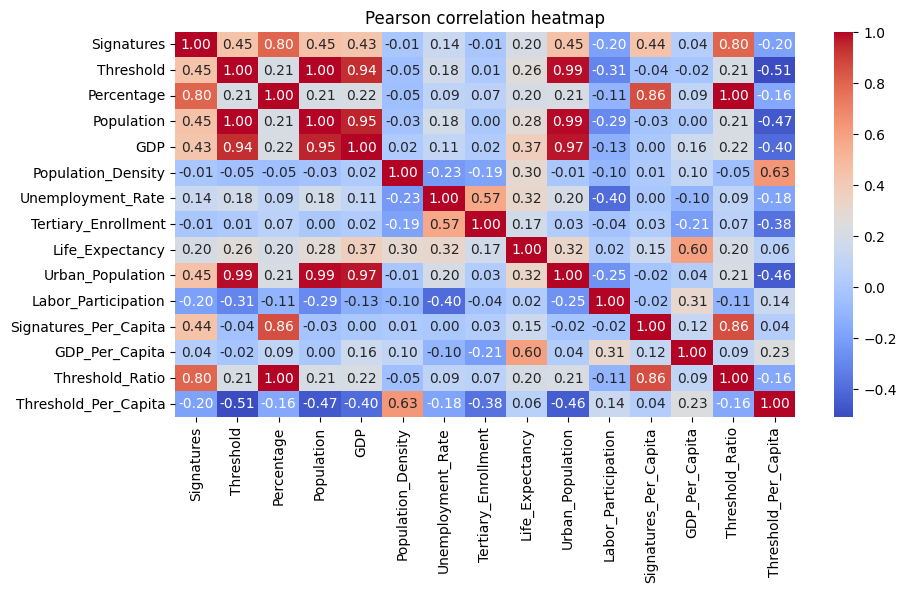

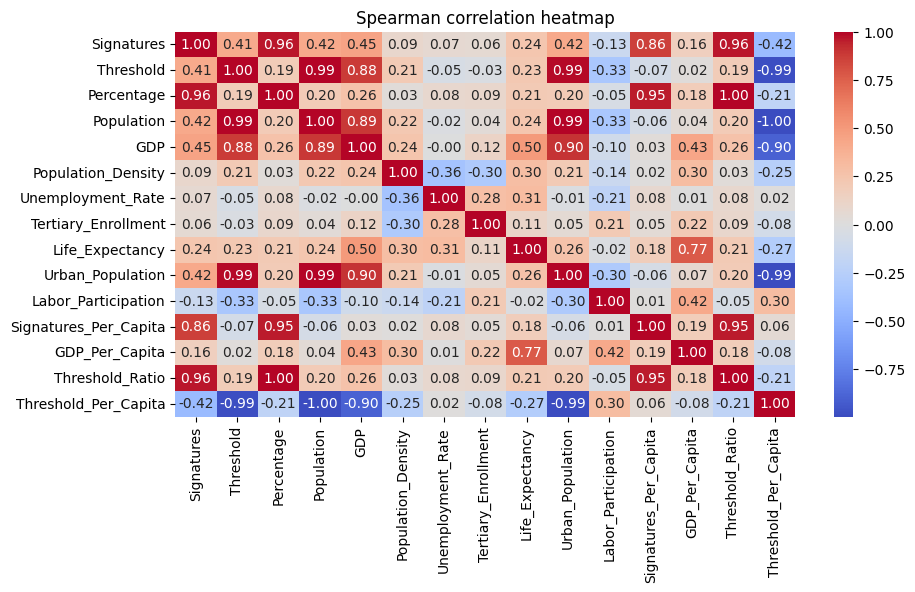

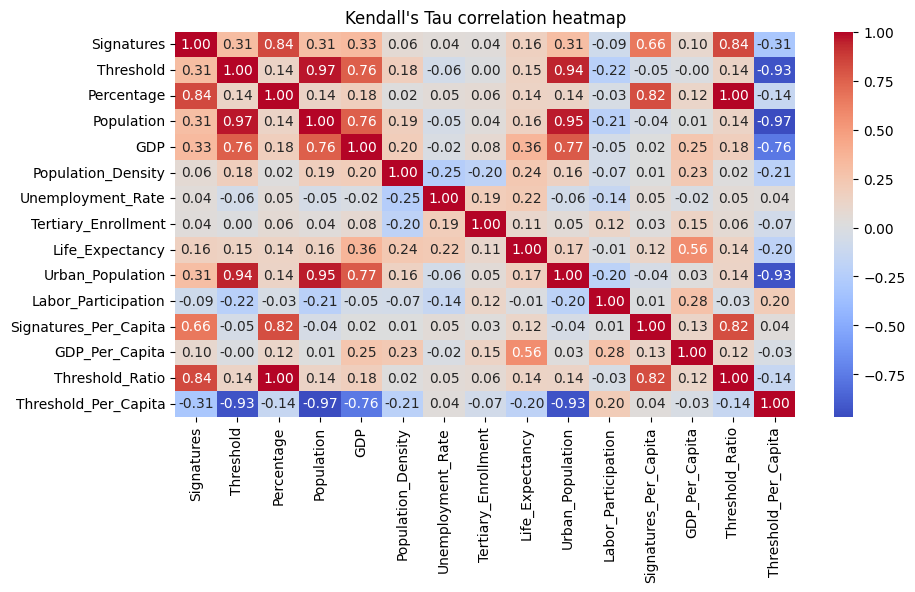

In [28]:
plt.figure(figsize=(10,5))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson correlation heatmap")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Spearman correlation heatmap")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Kendall's Tau correlation heatmap")
plt.show()

Population vs Threshold

The thresholds are almost identical population, this means that it provides limited additional information to any analysis


Threshold Ratio vs Percentage

Both variables are identical meaning that having both brings little additional value


Population vs Urban Population

Urban population is highly correlated with total population this may leand to multi colinearity


GDP Per Capitavs Signatures Per Capita

This shows a weak positive relationship, this suggests that it is not a major indicator of participation


Socio-economic variables appear to show weak linear relationships with ECI participation rates

In [29]:
selected_data = merged_data[
[
    "Signatures_Per_Capita",
    "Population",
    "GDP_Per_Capita",
    "Unemployment_Rate",
    "Tertiary_Enrollment",
    "Life_Expectancy",
    "Population_Density",
    "Labor_Participation"
]
]

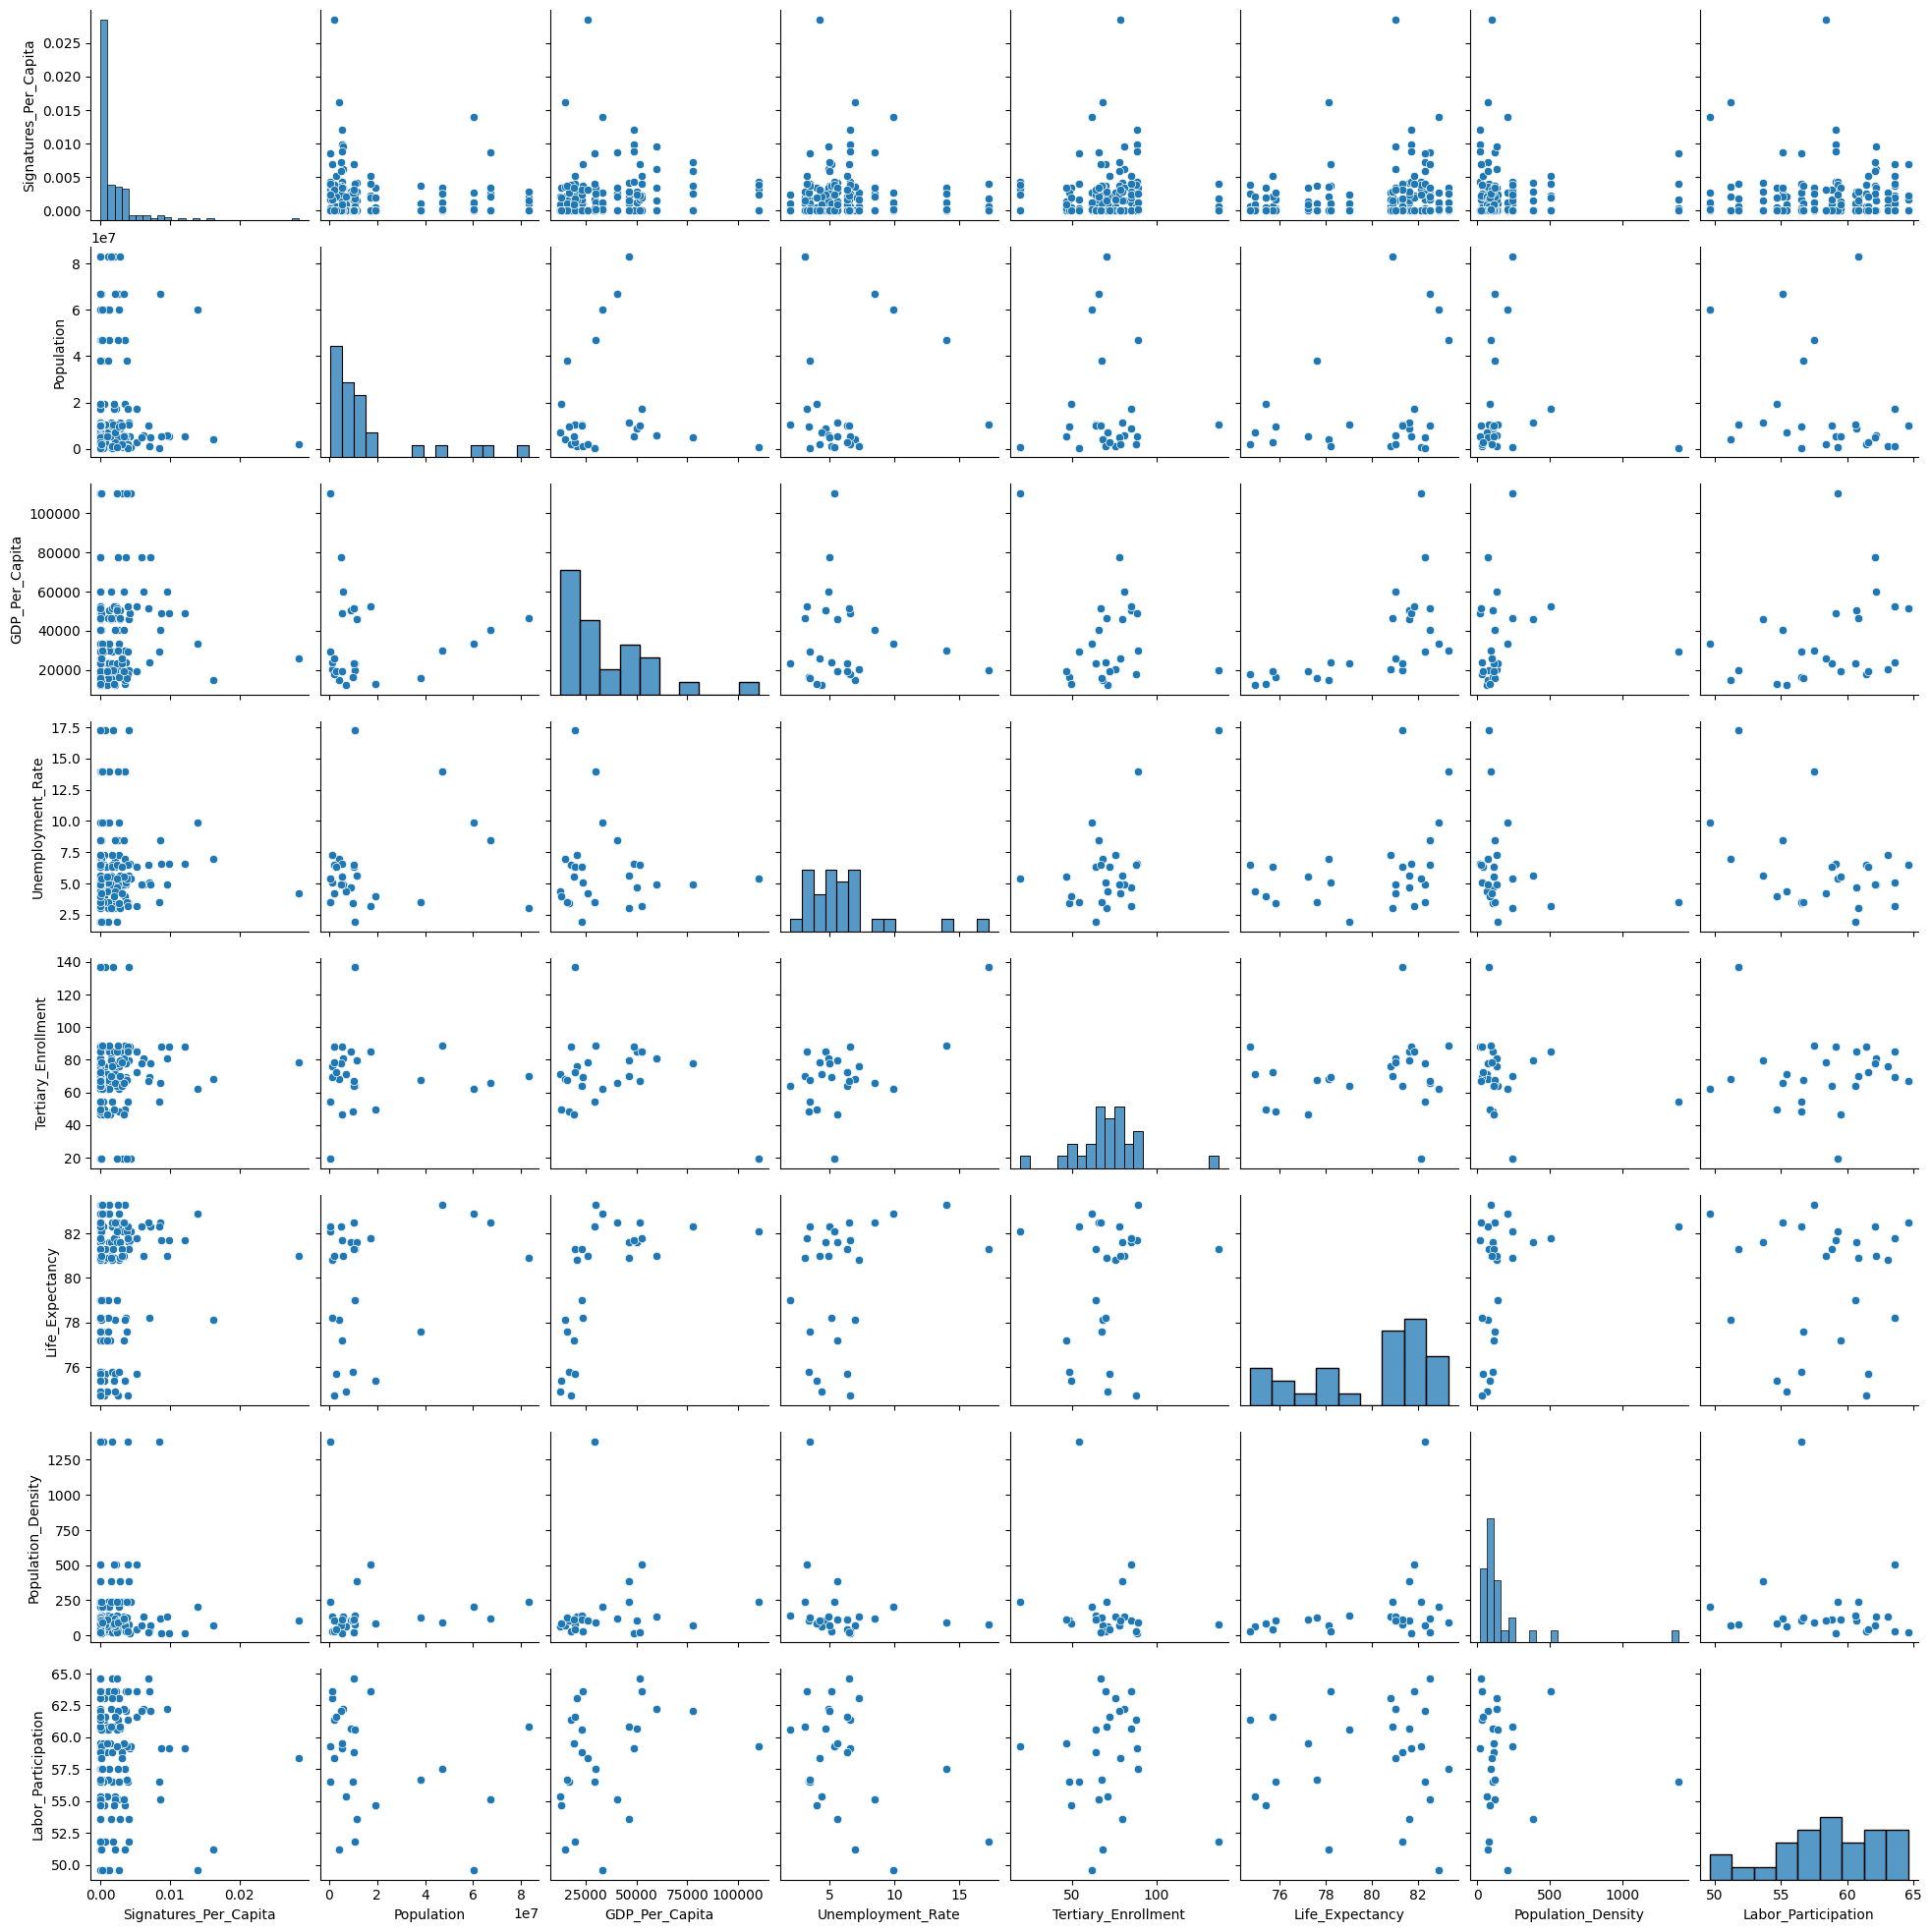

In [30]:
sns.pairplot(selected_data)

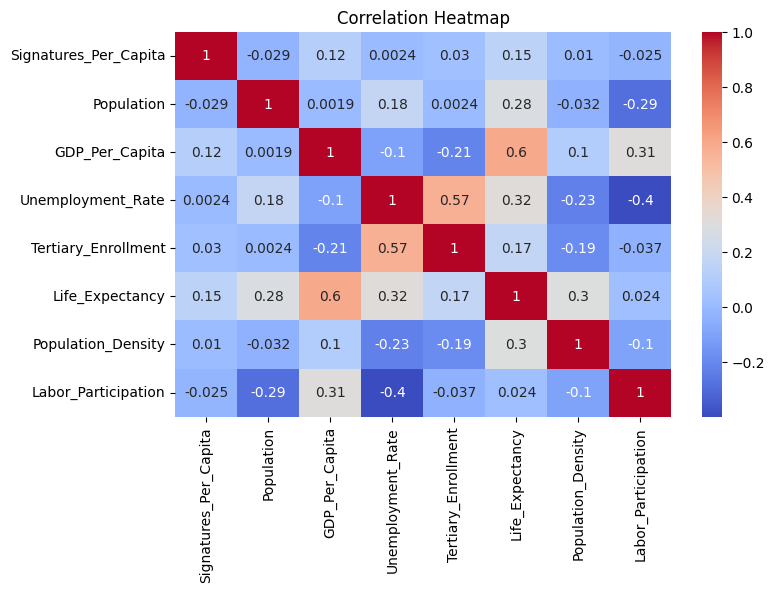

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(selected_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Signatures_Per_Capita

- Population
- GDP_Per_Capita
- Unemployment_Rate
- Tertiary_Enrollment
- Life_Expectancy
- Population_Density
- Labor_Participation

In [32]:
merged_data.nlargest(
    10,
    "Signatures_Per_Capita"
)

,Country,Signatures,Threshold,Percentage,Petition_ID,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio,Threshold_Per_Capita,Petition_Name
78,Slovenia,59508,5640,1055.11,eci_table_04,2087946.0,5.374216e+10,103,4.20,78.6,81.0,1144654.0,58.4,0.028501,25739.247814,10.551064,0.002701,My Voice My Choice
57,Croatia,65963,8460,779.70,eci_table_04,4067500.0,6.041555e+10,73,6.93,67.9,78.1,2328318.0,51.2,0.016217,14853.239837,7.797045,0.002080,My Voice My Choice
176,Italy,841188,53580,1569.97,eci_table_09,60297396.0,2.001244e+12,206,9.89,61.9,82.9,42651966.0,49.6,0.013951,33189.565799,15.699664,0.000889,STOP FAKE FOOD: ORIGIN ON LABEL
62,Finland,66565,9870,674.42,eci_table_04,5520314.0,2.687612e+11,18,6.59,88.2,81.7,4716888.0,59.1,0.012058,48685.853987,6.744174,0.001788,My Voice My Choice
116,Finland,54538,9870,552.56,eci_table_07,5520314.0,2.687612e+11,18,6.59,88.2,81.7,4716888.0,59.1,0.009880,48685.853987,5.525633,0.001788,Stop Destroying Videogames
141,Denmark,56088,9870,568.27,eci_table_08,5818553.0,3.480780e+11,137,4.91,80.6,81.0,5119978.0,62.2,0.009640,59822.092961,5.682675,0.001696,Stop Cruelty Stop Slaughter
143,Finland,48444,9870,490.82,eci_table_08,5520314.0,2.687612e+11,18,6.59,88.2,81.7,4716888.0,59.1,0.008776,48685.853987,4.908207,0.001788,Stop Cruelty Stop Slaughter
9,France,580568,55695,1042.41,eci_table_01,67059887.0,2.715518e+12,119,8.43,65.6,82.5,54123364.0,55.1,0.008657,40493.928572,10.424060,0.000831,Ban Conversion Practices
72,Malta,4278,4230,101.13,eci_table_04,502653.0,1.478616e+10,1380,3.47,54.3,82.3,475902.0,56.5,0.008511,29416.230606,1.011348,0.008415,My Voice My Choice
121,Republic of Ireland,36073,9165,393.60,eci_table_07,5007069.0,3.886987e+11,72,4.93,77.8,82.3,3133123.0,62.1,0.007204,77629.988991,3.935952,0.001830,Stop Destroying Videogames


<Axes: xlabel='Threshold_Per_Capita', ylabel='Percentage'>

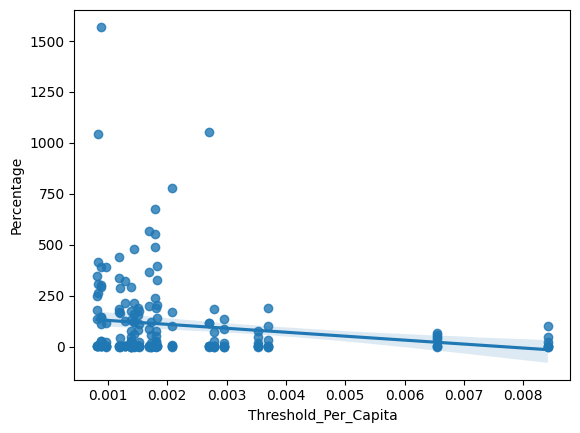

In [33]:
sns.regplot(
    data=merged_data,
    x="Threshold_Per_Capita",
    y="Percentage"
)

### EDA findings:

Rates of participation appear to vary substantially between different petitions

Petition topic appears to influence participation more strongly than country-level socio-economic variables

GDP per capita exhibits only a weak relationship with signatures per capita

GDP alone does not appear to be a strong predictor of participation rates

Population and ECI thresholds are almost perfectly correlated, furthermore, Population and Threshold share the exact same correlations vs every other variable i.e. they are essentially the same 

Threshold ratio and percentage are also essentially the same 

Country-level socioeconomic variables appear to explain only a small proportion of variation in ECI participation 

Thresholds may represent a greater burden for smaller populations showing that further investigation may be needed with Threshold per Capita

This suggests the greatest variation may be due to petition topic etc.

For future work:

- Incoportate more petitions (10-20 petitions)
- Explore and Incorporate New variables such as internet literacy, voter turnout, trust in government etc
- Final feature selection
- ANOVA on petitions
- Regressions
- PCA
- Clustering
- Machine learning
